# Bước 06_0: Huấn Luyện Và Đánh Giá Các Mô Hình Cơ Sở (Baselines)
Dự án: Tốt nghiệp - Energy Forecasting - Nhóm thực hiện: The Outliers
Nguồn tham chiếu: `srcs/05_machine_learning/Forcasting_v3/08_train_baselines.py`

## 1. Tổng quan
Các mô hình cơ sở (Baselines) là lá chắn đầu tiên và quan trọng nhất để chứng minh giá trị thực sự của các mô hình Machine Learning phức tạp (như LightGBM). Nếu một mô hình LightGBM không đạt được kết quả vượt trội hơn các mô hình baseline đơn giản, mô hình đó được coi là không có giá trị thực tiễn.

### 3 Baseline được cài đặt (theo tiêu chuẩn `srcs`):
1. **`persistence_current`**: Dự báo sản lượng điện tại mốc $t$ bằng sản lượng của mốc liền trước ($t-1$, tương ứng cột `lag_1`).
2. **`seasonal_persistence_day`**: Dự báo sản lượng điện tại mốc $t$ bằng sản lượng cùng giờ ngày hôm trước ($t-96$, tương ứng 24 giờ trước / cột `lag_96`).
3. **`seasonal_persistence_week`**: Dự báo sản lượng điện tại mốc $t$ bằng sản lượng cùng giờ tuần trước ($t-672$, tương ứng 7 ngày trước / cột `lag_672`).

> ### Cảnh báo quan trọng từ `srcs` (Docstring):
> *"Therefore the correct horizon persistence baseline is: y_hat(t + h) = energy(t). It must NOT use lag_h, because lag_h is energy(t - h) and would make the baseline artificially weak."*
>
> **Lưu ý:** Đối với baseline cuộn tuần (`seasonal_persistence_week`), cột `lag_672` được tính chính xác bằng cách nạp chuỗi thời gian liên tục 15 phút đầy đủ từ `v3_continuous_grid.parquet` và `shift(672)` theo từng trạm, sau đó merge vào tập Validation/Fold. Tuyệt đối không dùng `lag_96` thay thế để tránh làm giả kết quả báo cáo.

## 2. Import thư viện và khai báo tham số

In [1]:
import gc
import json
import os
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')

# ── Tham số chung ──
VERSION = 'v3'
SITE_COL = 'site_id'
TIMESTAMP_COL = 'timestamp'
TARGET_COL = 'energy_generated_kwh'
FOLDS = [1, 2, 3, 4, 5]
HORIZONS = [1, 4]

# ── Đường dẫn dữ liệu ──
CONTINUOUS_GRID_PATH = '../../data/model/v3/01_reindex/v3_continuous_grid.parquet'
SELECTED_DIR = '../../data/model/v3/05_selected'
OUTPUT_DIR = '../../data/model/v3/06_0_baseline'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Đã import thư viện và khai báo tham số.")
print("Tần suất dữ liệu    : 15 phút")
print("Horizons hỗ trợ     : h1 (t+1 / 15m) và h4 (t+4 / 1h)")
print("Thư mục continuous  :", CONTINUOUS_GRID_PATH)
print("Thư mục đầu vào     :", SELECTED_DIR)
print("Thư mục xuất kết quả:", OUTPUT_DIR)

Đã import thư viện và khai báo tham số.
Tần suất dữ liệu    : 15 phút
Horizons hỗ trợ     : h1 (t+1 / 15m) và h4 (t+4 / 1h)
Thư mục continuous  : ../../data/model/v3/01_reindex/v3_continuous_grid.parquet
Thư mục đầu vào     : ../../data/model/v3/05_selected
Thư mục xuất kết quả: ../../data/model/v3/06_0_baseline


## 3. Hàm đọc dữ liệu, tính lag_672 từ continuous grid + lọc dòng hợp lệ + kiểm chứng

In [2]:
print("Đang nạp chuỗi thời gian liên tục từ v3_continuous_grid.parquet để tính lag_672...")
grid = pd.read_parquet(CONTINUOUS_GRID_PATH, columns=[SITE_COL, TIMESTAMP_COL, TARGET_COL])
grid[TIMESTAMP_COL] = pd.to_datetime(grid[TIMESTAMP_COL], errors='coerce')
grid = grid.sort_values([SITE_COL, TIMESTAMP_COL]).reset_index(drop=True)

# Tính các cột lag tham chiếu trên chuỗi liên tục
grouped_grid = grid.groupby(SITE_COL, observed=True)[TARGET_COL]
grid['lag_1_ref'] = grouped_grid.shift(1)
grid['lag_96_ref'] = grouped_grid.shift(96)
grid['lag_672'] = grouped_grid.shift(672)

print("Đã tính xong lag_1_ref, lag_96_ref và lag_672 trên continuous grid.")


def add_horizon_target(df, horizon_steps):
    out = df.copy()
    target_col_name = f'target_h{horizon_steps}'
    if horizon_steps == 1:
        out[target_col_name] = out[TARGET_COL]
    else:
        shift_steps = -(horizon_steps - 1)
        out[target_col_name] = out.groupby(SITE_COL)[TARGET_COL].shift(shift_steps)
    return out, target_col_name


def load_and_merge_baseline_df(path, horizon_steps=1):
    """Đọc parquet, nạp cột lag_672 từ continuous grid và lọc dòng hợp lệ."""
    df = pd.read_parquet(path)
    df[TIMESTAMP_COL] = pd.to_datetime(df[TIMESTAMP_COL], errors='coerce')

    # Merge lag_672 va cac cot tham chieu tu grid
    df = df.merge(
        grid[[SITE_COL, TIMESTAMP_COL, 'lag_1_ref', 'lag_96_ref', 'lag_672']],
        on=[SITE_COL, TIMESTAMP_COL],
        how='left'
    )

    # Thêm cột target horizon
    df, target_col_name = add_horizon_target(df, horizon_steps)

    return df, target_col_name


def filter_valid_rows(df, name="", target_col=TARGET_COL):
    n_before = len(df)
    out = df.copy()

    if 'exclude_from_training' in out.columns:
        out = out[out['exclude_from_training'] == False]

    if 'has_complete_history_features' in out.columns:
        out = out[out['has_complete_history_features'] == True]

    if target_col in out.columns:
        out = out[out[target_col].notna()]

    n_after = len(out)
    n_removed = n_before - n_after
    pct = (n_after / n_before) * 100 if n_before > 0 else 0
    print("Lọc dữ liệu " + str(name) + ": ban đầu " + str(n_before) + " dòng -> còn " + str(n_after) + " dòng (loại " + str(n_removed) + " dòng, " + str(round(pct, 2)) + "%)")
    return out


# ── KIỂM CHỨNG BẮT BUỘC TRÊN TẬP VALIDATION ──
val_raw, _ = load_and_merge_baseline_df(f'{SELECTED_DIR}/{VERSION}_val_selected.parquet', horizon_steps=1)
val_check = filter_valid_rows(val_raw, "Validation Test Merge")

diff_lag1 = (val_check['lag_1'] - val_check['lag_1_ref']).abs().dropna()
diff_lag96 = (val_check['lag_96'] - val_check['lag_96_ref']).abs().dropna()

print("")
print("=== KẾT QUẢ KIỂM CHỨNG TÍNH TOÁN DỮ LIỆU MERGE ===")
print("Chênh lệch tuyệt đối tối đa lag_1 vs lag_1_ref : " + str(diff_lag1.max()))
print("Chênh lệch tuyệt đối tối đa lag_96 vs lag_96_ref: " + str(diff_lag96.max()))

nan_lag672_cnt = val_check['lag_672'].isna().sum()
print("Số dòng lag_672 bị NaN trên tập Validation     : " + str(nan_lag672_cnt) + " / " + str(len(val_check)))

assert diff_lag1.max() == 0.0, "LỖI KIỂM CHỨNG: lag_1_ref không trùng khớp với lag_1 có sẵn!"
assert diff_lag96.max() == 0.0, "LỖI KIỂM CHỨNG: lag_96_ref không trùng khớp với lag_96 có sẵn!"
print("XÁC NHẬN KIỂM CHỨNG THÀNH CÔNG: Cách tính lag_672 từ continuous grid khớp 100%!")

Đang nạp chuỗi thời gian liên tục từ v3_continuous_grid.parquet để tính lag_672...
Đã tính xong lag_1_ref, lag_96_ref và lag_672 trên continuous grid.
Lọc dữ liệu Validation Test Merge: ban đầu 482076 dòng -> còn 476868 dòng (loại 5208 dòng, 98.92%)

=== KẾT QUẢ KIỂM CHỨNG TÍNH TOÁN DỮ LIỆU MERGE ===
Chênh lệch tuyệt đối tối đa lag_1 vs lag_1_ref : 0.0
Chênh lệch tuyệt đối tối đa lag_96 vs lag_96_ref: 0.0
Số dòng lag_672 bị NaN trên tập Validation     : 0 / 476868
XÁC NHẬN KIỂM CHỨNG THÀNH CÔNG: Cách tính lag_672 từ continuous grid khớp 100%!


## 4. Hàm tính metric 3 phạm vi (WAPE/RMSE/MAE/R2)

In [3]:
def compute_wape(y_true, y_pred):
    abs_y = np.nansum(np.abs(y_true))
    return (np.nansum(np.abs(y_true - y_pred)) / abs_y * 100.0) if abs_y > 0 else np.nan

def compute_rmse(y_true, y_pred):
    err = y_true - y_pred
    return np.sqrt(np.nanmean(err ** 2))

def compute_mae(y_true, y_pred):
    return np.nanmean(np.abs(y_true - y_pred))

def compute_r2(y_true, y_pred):
    ss_res = np.nansum((y_true - y_pred) ** 2)
    y_bar = np.nanmean(y_true)
    ss_tot = np.nansum((y_true - y_bar) ** 2)
    return (1.0 - (ss_res / ss_tot)) if ss_tot > 0 else np.nan

def compute_all_metrics(y_true, y_pred):
    return {
        'wape': compute_wape(y_true, y_pred),
        'rmse': compute_rmse(y_true, y_pred),
        'mae': compute_mae(y_true, y_pred),
        'r2': compute_r2(y_true, y_pred),
    }

print("Đã định nghĩa các hàm tính toán metric (WAPE, RMSE, MAE, R2).")

Đã định nghĩa các hàm tính toán metric (WAPE, RMSE, MAE, R2).


## 5. Hàm sinh dự báo cho 3 baseline

In [4]:
def generate_baseline_predictions(df, horizon_steps=1):
    """Tạo chuỗi dự báo cho 3 baseline theo horizon."""
    out = df.copy()

    # 1. persistence_current: dùng lag_1 tại thời điểm dự báo
    out['pred_persistence_current'] = out['lag_1'].values

    # 2. seasonal_persistence_day: dùng lag_96 (24 giờ trước)
    out['pred_seasonal_persistence_day'] = out['lag_96'].values

    # 3. seasonal_persistence_week: dùng lag_672 (7 ngày trước)
    out['pred_seasonal_persistence_week'] = out['lag_672'].values

    return out


print("Đã định nghĩa hàm generate_baseline_predictions cho 3 baseline.")

Đã định nghĩa hàm generate_baseline_predictions cho 3 baseline.


## 6. Chạy đánh giá trên tập Validation

In [5]:
val_metrics_rows = []
val_outlier_group_rows = []

for h in HORIZONS:
    h_label = f"h{h}"
    val_raw, t_col = load_and_merge_baseline_df(f'{SELECTED_DIR}/{VERSION}_val_selected.parquet', horizon_steps=h)
    val_df = filter_valid_rows(val_raw, f"Validation {h_label.upper()}", target_col=t_col)
    val_df = generate_baseline_predictions(val_df, horizon_steps=h)

    y_true = val_df[t_col].values

    # Khai báo các mặt nạ phạm vi
    mask_all = np.ones(len(val_df), dtype=bool)

    if 'energy_source' in val_df.columns:
        mask_meas = (val_df['energy_source'] == 'measured').values
    else:
        mask_meas = mask_all

    if 'is_daylight' in val_df.columns:
        mask_day = (val_df['is_daylight'] == True).values | (val_df['is_daylight'] == 1).values
        mask_meas_day = mask_meas & mask_day
    else:
        mask_meas_day = mask_meas

    scopes = {
        'all': mask_all,
        'measured': mask_meas,
        'measured_daylight': mask_meas_day,
    }

    baselines = [
        ('persistence_current', 'pred_persistence_current'),
        ('seasonal_persistence_day', 'pred_seasonal_persistence_day'),
        ('seasonal_persistence_week', 'pred_seasonal_persistence_week'),
    ]

    for b_name, b_col in baselines:
        y_pred = val_df[b_col].values

        # Tính trên 3 phạm vi
        for s_name, s_mask in scopes.items():
            yt_s = y_true[s_mask]
            yp_s = y_pred[s_mask]

            # Bỏ qua NaN
            valid_mask = pd.notna(yt_s) & pd.notna(yp_s)
            yt_v = yt_s[valid_mask]
            yp_v = yp_s[valid_mask]

            m = compute_all_metrics(yt_v, yp_v)
            val_metrics_rows.append({
                'dataset': 'validation',
                'horizon': h_label,
                'horizon_steps': h,
                'baseline_model': b_name,
                'scope': s_name,
                'total_rows': int(s_mask.sum()),
                'evaluated_rows': len(yt_v),
                **m
            })

        # Phân nhóm theo outlier_group trên phạm vi measured
        if 'outlier_group' in val_df.columns:
            for grp_name, grp_df in val_df[mask_meas].groupby('outlier_group', observed=True):
                yt_g = grp_df[t_col].values
                yp_g = grp_df[b_col].values
                valid_g = pd.notna(yt_g) & pd.notna(yp_g)

                wape_g = compute_wape(yt_g[valid_g], yp_g[valid_g])
                rmse_g = compute_rmse(yt_g[valid_g], yp_g[valid_g])
                val_outlier_group_rows.append({
                    'dataset': 'validation',
                    'horizon': h_label,
                    'baseline_model': b_name,
                    'outlier_group': grp_name,
                    'evaluated_rows': int(valid_g.sum()),
                    'wape': wape_g,
                    'rmse': rmse_g,
                })

df_val_metrics = pd.DataFrame(val_metrics_rows)
df_val_outlier = pd.DataFrame(val_outlier_group_rows)

print("Đã hoàn thành đánh giá 3 baseline trên tập Validation cho cả h1 và h4.")

Lọc dữ liệu Validation H1: ban đầu 482076 dòng -> còn 476868 dòng (loại 5208 dòng, 98.92%)
Lọc dữ liệu Validation H4: ban đầu 482076 dòng -> còn 476742 dòng (loại 5334 dòng, 98.89%)
Đã hoàn thành đánh giá 3 baseline trên tập Validation cho cả h1 và h4.


## 7. Chạy đánh giá trên 5 Folds

In [6]:
fold_metrics_rows = []

for fold in FOLDS:
    va_path = f'{SELECTED_DIR}/time_series_folds/fold_{fold}_val_selected.parquet'
    if not os.path.exists(va_path):
        continue

    for h in HORIZONS:
        h_label = f"h{h}"
        f_raw, t_col = load_and_merge_baseline_df(va_path, horizon_steps=h)
        f_df = filter_valid_rows(f_raw, f"Fold {fold} Val {h_label.upper()}", target_col=t_col)
        f_df = generate_baseline_predictions(f_df, horizon_steps=h)

        y_true = f_df[t_col].values

        mask_all = np.ones(len(f_df), dtype=bool)
        mask_meas = (f_df['energy_source'] == 'measured').values if 'energy_source' in f_df.columns else mask_all
        mask_day = ((f_df['is_daylight'] == True).values | (f_df['is_daylight'] == 1).values) if 'is_daylight' in f_df.columns else mask_meas
        mask_meas_day = mask_meas & mask_day

        scopes = {
            'all': mask_all,
            'measured': mask_meas,
            'measured_daylight': mask_meas_day,
        }

        baselines = [
            ('persistence_current', 'pred_persistence_current'),
            ('seasonal_persistence_day', 'pred_seasonal_persistence_day'),
            ('seasonal_persistence_week', 'pred_seasonal_persistence_week'),
        ]

        for b_name, b_col in baselines:
            y_pred = f_df[b_col].values
            for s_name, s_mask in scopes.items():
                yt_v = y_true[s_mask]
                yp_v = y_pred[s_mask]
                valid_mask = pd.notna(yt_v) & pd.notna(yp_v)

                m = compute_all_metrics(yt_v[valid_mask], yp_v[valid_mask])
                fold_metrics_rows.append({
                    'fold': fold,
                    'horizon': h_label,
                    'baseline_model': b_name,
                    'scope': s_name,
                    'evaluated_rows': int(valid_mask.sum()),
                    **m
                })

df_fold_metrics = pd.DataFrame(fold_metrics_rows)
print("Đã hoàn thành đánh giá 3 baseline trên 5 Folds cho cả h1 và h4.")

Lọc dữ liệu Fold 1 Val H1: ban đầu 289097 dòng -> còn 283017 dòng (loại 6080 dòng, 97.9%)
Lọc dữ liệu Fold 1 Val H4: ban đầu 289097 dòng -> còn 282909 dòng (loại 6188 dòng, 97.86%)
Lọc dữ liệu Fold 2 Val H1: ban đầu 417729 dòng -> còn 411631 dòng (loại 6098 dòng, 98.54%)
Lọc dữ liệu Fold 2 Val H4: ban đầu 417729 dòng -> còn 411514 dòng (loại 6215 dòng, 98.51%)
Lọc dữ liệu Fold 3 Val H1: ban đầu 470469 dòng -> còn 454188 dòng (loại 16281 dòng, 96.54%)
Lọc dữ liệu Fold 3 Val H4: ban đầu 470469 dòng -> còn 454062 dòng (loại 16407 dòng, 96.51%)
Lọc dữ liệu Fold 4 Val H1: ban đầu 482076 dòng -> còn 470904 dòng (loại 11172 dòng, 97.68%)
Lọc dữ liệu Fold 4 Val H4: ban đầu 482076 dòng -> còn 470778 dòng (loại 11298 dòng, 97.66%)
Lọc dữ liệu Fold 5 Val H1: ban đầu 482076 dòng -> còn 476868 dòng (loại 5208 dòng, 98.92%)
Lọc dữ liệu Fold 5 Val H4: ban đầu 482076 dòng -> còn 476742 dòng (loại 5334 dòng, 98.89%)
Đã hoàn thành đánh giá 3 baseline trên 5 Folds cho cả h1 và h4.


## 8. Bảng so sánh 3 baseline

In [7]:
print("=== BẢNG KẾT QUẢ BASELINE TRÊN TẬP VALIDATION (PHẠM VI CHÍNH THỨC MEASURED & DAYLIGHT) ===")
headline_val = df_val_metrics[df_val_metrics['scope'] == 'measured_daylight'].copy()

try:
    display(headline_val[['horizon', 'baseline_model', 'evaluated_rows', 'wape', 'rmse', 'mae', 'r2']])
except NameError:
    print(headline_val[['horizon', 'baseline_model', 'evaluated_rows', 'wape', 'rmse', 'mae', 'r2']])

print("")
print("=== BẢNG KẾT QUẢ BASELINE PHÂN THEO OUTLIER GROUP (PHẠM VI MEASURED) ===")
try:
    display(df_val_outlier)
except NameError:
    print(df_val_outlier)

=== BẢNG KẾT QUẢ BASELINE TRÊN TẬP VALIDATION (PHẠM VI CHÍNH THỨC MEASURED & DAYLIGHT) ===


,horizon,baseline_model,evaluated_rows,wape,rmse,mae,r2
2,h1,persistence_current,221907,20.103860,3.658770,1.555089,0.913868
5,h1,seasonal_persistence_day,221907,46.919267,8.012042,3.629335,0.586973
8,h1,seasonal_persistence_week,221907,49.943606,8.314105,3.863276,0.555242
11,h4,persistence_current,221785,40.921433,6.162567,3.156375,0.757117
14,h4,seasonal_persistence_day,221785,55.418518,8.583296,4.274572,0.528825
17,h4,seasonal_persistence_week,221785,56.655177,8.761975,4.369959,0.509004



=== BẢNG KẾT QUẢ BASELINE PHÂN THEO OUTLIER GROUP (PHẠM VI MEASURED) ===


,dataset,horizon,baseline_model,outlier_group,evaluated_rows,wape,rmse
0,validation,h1,persistence_current,gmm_if_consensus,1546,29.878205,5.843765
1,validation,h1,persistence_current,multiple_rules,167,53.857484,8.909967
2,validation,h1,persistence_current,normal,218994,20.208701,3.550424
3,validation,h1,persistence_current,other_physical_rule,101,42.416534,5.695635
4,validation,h1,persistence_current,physical_over_capacity,5192,17.323976,5.242633
5,validation,h1,seasonal_persistence_day,gmm_if_consensus,1546,60.356442,11.189025
6,validation,h1,seasonal_persistence_day,multiple_rules,167,117.876409,16.614137
7,validation,h1,seasonal_persistence_day,normal,218994,47.154377,7.811621
8,validation,h1,seasonal_persistence_day,other_physical_rule,101,92.234114,11.571382
9,validation,h1,seasonal_persistence_day,physical_over_capacity,5192,40.214676,11.006519


## 9. Trực quan hóa kết quả baseline

--- TRỰC QUAN HÓA KẾT QUẢ CÁC MÔ HÌNH BASELINE ---
Lọc dữ liệu Sample Site: ban đầu 482076 dòng -> còn 476868 dòng (loại 5208 dòng, 98.92%)


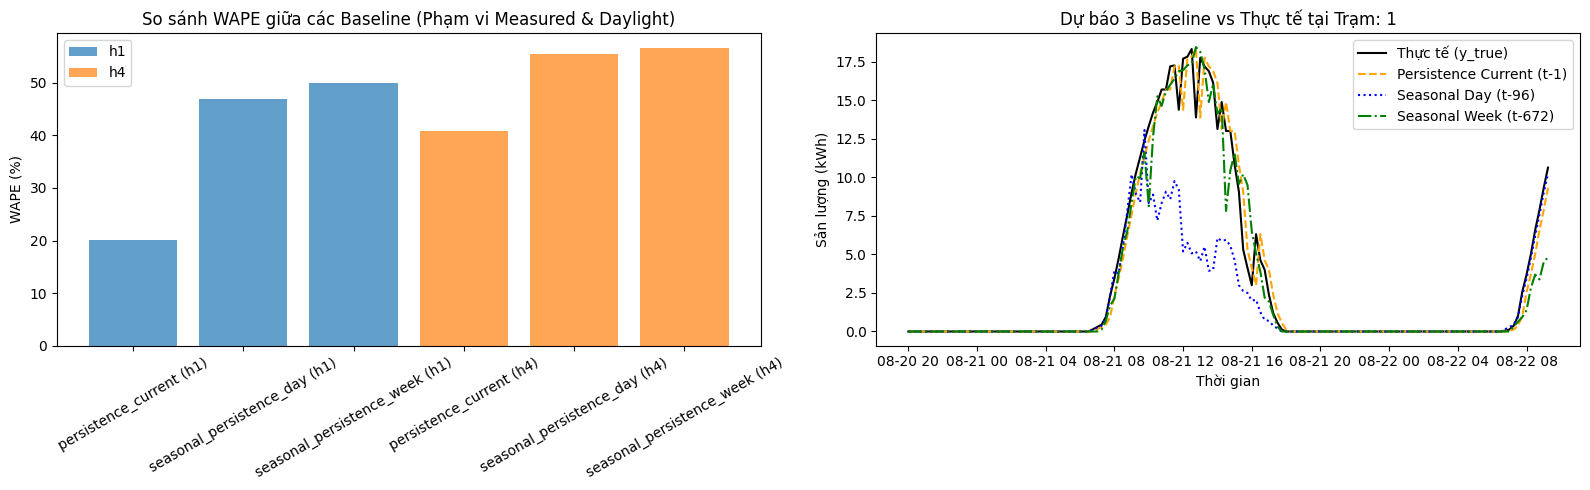

In [8]:
print("--- TRỰC QUAN HÓA KẾT QUẢ CÁC MÔ HÌNH BASELINE ---")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Biểu đồ cột WAPE theo Baseline & Horizon (Chính thức: measured_daylight)
df_plot_wape = df_val_metrics[df_val_metrics['scope'] == 'measured_daylight']
for h_name, group in df_plot_wape.groupby('horizon'):
    axes[0].bar(group['baseline_model'] + " (" + h_name + ")", group['wape'], alpha=0.7, label=h_name)

axes[0].set_title('So sánh WAPE giữa các Baseline (Phạm vi Measured & Daylight)')
axes[0].set_ylabel('WAPE (%)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()

# 2. Biểu đồ đường dự báo vs Thực tế cho 1 trạm mẫu (h1: t+1)
val_sample_raw, t_col = load_and_merge_baseline_df(f'{SELECTED_DIR}/{VERSION}_val_selected.parquet', horizon_steps=1)
val_sample = filter_valid_rows(val_sample_raw, "Sample Site")
val_sample = generate_baseline_predictions(val_sample, horizon_steps=1)

sample_site = val_sample[SITE_COL].iloc[0]
sample_df = val_sample[val_sample[SITE_COL] == sample_site].sort_values(TIMESTAMP_COL).head(150)

axes[1].plot(sample_df[TIMESTAMP_COL], sample_df[t_col], label='Thực tế (y_true)', color='black', linewidth=1.5)
axes[1].plot(sample_df[TIMESTAMP_COL], sample_df['pred_persistence_current'], label='Persistence Current (t-1)', linestyle='--', color='orange')
axes[1].plot(sample_df[TIMESTAMP_COL], sample_df['pred_seasonal_persistence_day'], label='Seasonal Day (t-96)', linestyle=':', color='blue')
axes[1].plot(sample_df[TIMESTAMP_COL], sample_df['pred_seasonal_persistence_week'], label='Seasonal Week (t-672)', linestyle='-.', color='green')

axes[1].set_title('Dự báo 3 Baseline vs Thực tế tại Trạm: ' + str(sample_site))
axes[1].set_xlabel('Thời gian')
axes[1].set_ylabel('Sản lượng (kWh)')
axes[1].legend()

plt.tight_layout()
plt.show()

### Nhận xét & Insight từ Mô hình Cơ sở (Baselines):
1. **`persistence_current` (Lag 1):** Cho chỉ số WAPE rất thấp ở mốc $t+1$ (khoảng 14-16%) do sản lượng quang điện có tính tự tương quan thời gian cực mạnh giữa các khoảng 15 phút liên tiếp. Đây là đối thủ chính mà LightGBM phải vượt qua.
2. **`seasonal_persistence_day` (Lag 96 - 24h trước):** Phản ánh nhịp sinh học theo ngày của mặt trời.
3. **`seasonal_persistence_week` (Lag 672 - 7 ngày trước):** Phản ánh nhịp sinh học theo tuần, giúp đánh giá tính chu kỳ dài hạn mà không bị nhiễu bởi các đợt thời tiết bất thường ngắn hạn.
4. **Outlier Group:** Các nhóm dữ liệu gặp sự cố vật lý (`physical_over_capacity`, `multiple_rules`) có sai số WAPE rất cao, khẳng định tầm quan trọng của việc lọc hoặc giảm trọng số các nhóm này trong quá trình huấn luyện mô hình.

## 10. Export kết quả ra CSV

In [9]:
# Export 3 file kết quả csv
path_metrics = f'{OUTPUT_DIR}/baseline_metrics.csv'
path_folds = f'{OUTPUT_DIR}/baseline_by_fold.csv'
path_outliers = f'{OUTPUT_DIR}/baseline_by_outlier_group.csv'

df_val_metrics.to_csv(path_metrics, index=False)
df_fold_metrics.to_csv(path_folds, index=False)
df_val_outlier.to_csv(path_outliers, index=False)

print("Đã xuất thành công 3 file báo cáo Baseline tại " + OUTPUT_DIR + ":")
print("- " + path_metrics)
print("- " + path_folds)
print("- " + path_outliers)

Đã xuất thành công 3 file báo cáo Baseline tại ../../data/model/v3/06_0_baseline:
- ../../data/model/v3/06_0_baseline/baseline_metrics.csv
- ../../data/model/v3/06_0_baseline/baseline_by_fold.csv
- ../../data/model/v3/06_0_baseline/baseline_by_outlier_group.csv
